# SHAP in presence of data with high degree of multicollinearity

### kernelSHAP breaks the assumption that there exists dependency among features and thus can lead to biased and in some cases even attribute opposite directionality for explanations (Aas et al. 2021)

<img src="embedded_images/corrected shap" alt="drawing" width="700"/>

### Aas et al. suggested a modification using an emperical conditional distribution approximation method. They have also released as a package (shaprpy). Installation details can be found here: https://norskregnesentral.github.io/shapr/shaprpy.html

# 1. Load the shaprpy package and relevant modules

In [1]:
"""
@author: Shreyash Garg, created Feb 2026 ibmi spring school

Load shaprpy module
"""

from sklearn.ensemble import RandomForestRegressor
from shaprpy import explain
from shaprpy.datasets import load_california_housing


# 2. How to use shaprpy

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/envs/ibmi/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <05EE76C0-33BF-3D4C-BC56-84005241BC88> /opt/anaconda3/envs/ibmi/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.



── Starting `shapr::explain()` from Python at 2026-03-03 12:17:58 ──────────────
ℹ Feature classes extracted from the model contain `NA`.
  Assuming feature classes from the data are correct.
ℹ `max_n_coalitions` is `NULL` or larger than `2^n_features = 256`, and is
  therefore set to `2^n_features = 256`.

── Explanation overview ──

• Model class: <sklearn.ensemble._forest.RandomForestRegressor>
• v(S) estimation class: Monte Carlo integration
• Approach: empirical
• Procedure: Iterative
• Number of Monte Carlo integration samples: 1000
• Number of feature-wise Shapley values: 8
• Number of observations to explain: 5
• Computations (temporary) saved at:
'/var/folders/bk/xg2k7pnj5g70rbp3c7mlq1780000gn/T//RtmpeqnkFB/shapr_obj_514e6a8c6cb1.rds'

── Iterative computation started ──

── Iteration 1 ─────────────────────────────────────────────────────────────────
ℹ Using 26 of 256 coalitions, 26 new. 

── Iteration 2 ─────────────────────────────────────────────────────────────────
ℹ Usi

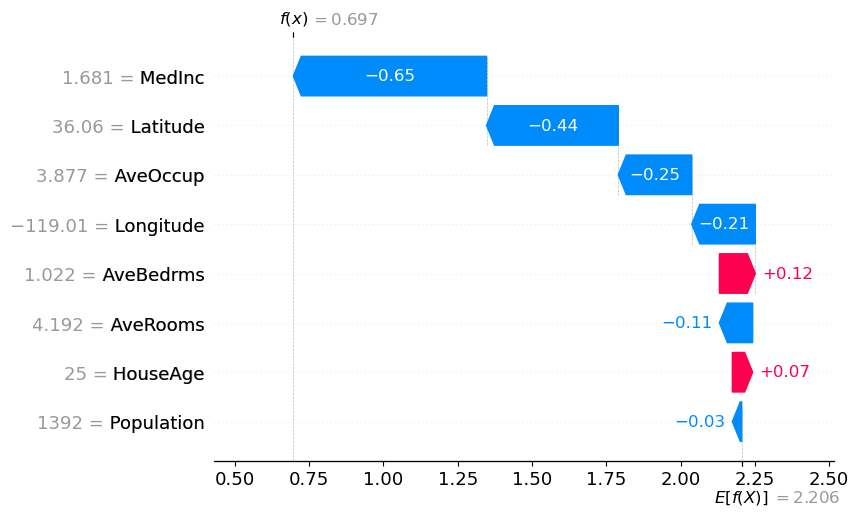

In [2]:
# Load example data
dfx_train, dfx_test, dfy_train, dfy_test = load_california_housing()

# Fit a model
model = RandomForestRegressor()
model.fit(dfx_train, dfy_train.values.flatten())

# Explain predictions
explanation = explain(
    model=model,
    x_train=dfx_train,
    x_explain=dfx_test,
    approach="empirical",
    phi0=dfy_train.mean().item(),
    seed=1
)

explanation.print() # Print the Shapley values

# Get a summary object with computation details
summary = explanation.summary()
print(summary)  # Displays a formatted summary (also available directly via explanation.summary())

# Access specific summary attributes (available with tab-completion in Jupyter)
summary['approach']     # Approach used
summary['timing_summary']['total_time_secs']  # Total computation time

# Extract one or more specific result objects directly
explanation.get_results("proglang") # Programming language used (Python/R)
explanation.get_results("approach") # Approach used
explanation.get_results().keys()  # All available result objects

# Plotting (requires the 'shap' library)
# Convert to a SHAP Explanation object
shap_exp = explanation.to_shap()

import shap
shap.plots.waterfall(shap_exp[0]) # Plot the first observation

# 3. Hitting the compute limit

### The original code imposes a limit of 30 features. This feature exists as the complexity scales 2^n. For computing above SHAP values for data with more than 30 features, you would need to modify the source code which can be done by installing an editable version of the source code using -e flag during the installation. For more details visit https://norskregnesentral.github.io/shapr/shaprpy.html